In [ ]:
# Installer xgboost 
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import librairies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


In [ ]:

# Fonction d'entrainement 
def compare_models(df, target_col='diagnosis', test_size=0.2, random_state=42, save_models=True, output_dir='models'):
    """
    Compare plusieurs algorithmes de classification sur le dataset de cancer du sein.
    
    Paramètres
    ----------
    df : pd.DataFrame
        DataFrame contenant les données
    target_col : str
        Nom de la colonne cible (par défaut 'diagnosis')
    test_size : float
        Proportion du test set (par défaut 0.2)
    random_state : int
        Seed pour la reproductibilité (par défaut 42)
    save_models : bool
        Si True, sauvegarde le meilleur modèle et le scaler (par défaut True)
    output_dir : str
        Dossier de sauvegarde des modèles (par défaut 'models')
    
    Retourne
    --------
    results_df : pd.DataFrame
        DataFrame contenant les scores de recall pour chaque modèle
    fig : matplotlib.figure.Figure
        Graphique horizontal des performances
    fig_learning : matplotlib.figure.Figure
        Courbe d'apprentissage du meilleur modèle
    """
    
  
    # 1. Préparation des données
  
    # Sélectionner les features se terminant par "worst"
    worst_cols = [col for col in df.columns if col.endswith('_worst')]
    
    print(f"Features sélectionnées : {len(worst_cols)} colonnes '_worst'")
    
    # Séparer X et y
    X = df[worst_cols]
    y = df[target_col]
    
    # Encoder la cible si nécessaire (M=1, B=0)
    if y.dtype == 'object':
        y = y.map({'M': 1, 'B': 0})
    
   
    # 2. Split train/test
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state,
        stratify=y
    )
    
    print(f"Train set : {X_train.shape[0]} échantillons")
    print(f"Test set  : {X_test.shape[0]} échantillons")
    
   
    # 3. Mise à l'échelle MinMax
      
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("Mise à l'échelle MinMax appliquée\n")
    
   
    # 4. Définition des modèles
       
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state),
        'Random Forest': RandomForestClassifier(random_state=random_state),
        'Extra Trees': ExtraTreesClassifier(random_state=random_state),
        'XGBoost': XGBClassifier(random_state=random_state, eval_metric='logloss'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=random_state),
        'KNN': KNeighborsClassifier(),
        'AdaBoost': AdaBoostClassifier(random_state=random_state),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=random_state)
    }
    
   
    # 5. Entraînement et évaluation
      
    results = {}
    trained_models = {}
    
    print("Entraînement des modèles...\n")
    print("-" * 60)
    
    for name, model in models.items():
        # Entraînement
        model.fit(X_train_scaled, y_train)
        
        # Prédiction
        y_pred = model.predict(X_test_scaled)
        
        # Calcul du recall
        recall = recall_score(y_test, y_pred)
        results[name] = recall
        trained_models[name] = model
        
        print(f"{name:<30} | Recall: {recall:.4f}")
    
    print("-" * 60)
    
    
    # 6. Création du DataFrame de résultats
        
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Recall': list(results.values())
    }).sort_values('Recall', ascending=True)
    
   
    # 7. Visualisation
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.RdYlGn(results_df['Recall'])
    
    bars = ax.barh(
        results_df['Model'], 
        results_df['Recall'],
        color=colors,
        edgecolor='black',
        linewidth=1.2
    )
    
    # Annotations
    for i, (model, recall) in enumerate(zip(results_df['Model'], results_df['Recall'])):
        ax.text(
            recall + 0.01, 
            i, 
            f'{recall:.4f}',
            va='center',
            fontsize=10,
            fontweight='bold'
        )
    
    # Mise en forme
    ax.set_xlabel('Recall Score', fontsize=12, fontweight='bold')
    ax.set_title(
        'Comparaison des modèles - Métrique: Recall\n(Du moins performant au plus performant)',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.axvline(x=0.9, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Seuil 90%')
    ax.legend()
    
    plt.tight_layout()
    
    print(f"\nMeilleur modèle : {results_df.iloc[-1]['Model']} (Recall: {results_df.iloc[-1]['Recall']:.4f})")
    
    
    # 8. Rapport détaillé du meilleur modèle (AMÉLIORÉ)
    best_model_name = results_df.iloc[-1]['Model']
    best_model = trained_models[best_model_name]

    print(f"\n{'='*60}")
    print(f"RAPPORT DÉTAILLÉ - {best_model_name}")
    print(f"{'='*60}\n")

    y_pred_best = best_model.predict(X_test_scaled)

    # Classification Report amélioré avec mise en forme pro
    rapport_meilleur_model = classification_report(
        y_test, 
        y_pred_best, 
        target_names=['Bénin (0)', 'Malin (1)'],
        digits=4,
        zero_division=0
    )

    print("CLASSIFICATION REPORT")
    print("=" * 50)
    print(rapport_meilleur_model)
    print("=" * 50)
    print()
    
    # 9. Courbe d'apprentissage du meilleur modèle
    print(f"\n{'='*60}")
    print("Génération de la courbe d'apprentissage...")
    print(f"{'='*60}\n")
    
    # Recréer le modèle pour la courbe d'apprentissage
    best_model_fresh = models[best_model_name]
    
    train_sizes, train_scores, val_scores = learning_curve(
        best_model_fresh,
        X_train_scaled,
        y_train,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_log_loss',
        random_state=random_state
    )
    
    # Convertir en log-loss positif (plus c'est bas, mieux c'est)
    train_scores = -train_scores
    val_scores = -val_scores
    
    # Calculer les moyennes et écarts-types
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Créer le graphique
    fig_learning, ax_learning = plt.subplots(figsize=(10, 6))
    
    # Tracer les courbes
    ax_learning.plot(train_sizes, train_mean, 'o-', color='blue', label='Score d\'entraînement', linewidth=2)
    ax_learning.fill_between(
        train_sizes, 
        train_mean - train_std, 
        train_mean + train_std, 
        alpha=0.2, 
        color='blue'
    )
    
    ax_learning.plot(train_sizes, val_mean, 'o-', color='red', label='Score de validation', linewidth=2)
    ax_learning.fill_between(
        train_sizes, 
        val_mean - val_std, 
        val_mean + val_std, 
        alpha=0.2, 
        color='red'
    )
    
    # Mise en forme
    ax_learning.set_xlabel('Nombre d\'échantillons d\'entraînement', fontsize=12, fontweight='bold')
    ax_learning.set_ylabel('Log-Loss (plus bas = meilleur)', fontsize=12, fontweight='bold')
    ax_learning.set_title(
        f'Courbe d\'apprentissage - {best_model_name}\n(Métrique: Log-Loss)',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    ax_learning.legend(loc='upper right', fontsize=11)
    ax_learning.grid(True, alpha=0.3, linestyle='--')
    ax_learning.set_ylim(bottom=0)
    
    plt.tight_layout()
    
    print("✓ Courbe d'apprentissage générée avec succès")
    
    
    # 10. Sauvegarde du meilleur modèle et du scaler
    if save_models:
        # Créer le dossier de sortie s'il n'existe pas
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)
        
        # Sauvegarder le meilleur modèle
        model_filename = output_path / f"{best_model_name.lower().replace(' ', '_')}_best.pkl"
        with open(model_filename, 'wb') as f:
            pickle.dump(best_model, f)
        
        # Sauvegarder le scaler
        scaler_filename = output_path / "MinMax_scaler.pkl"
        with open(scaler_filename, 'wb') as f:
            pickle.dump(scaler, f)
        
        print(f"\n{'='*60}")
        print("MODÈLES SAUVEGARDÉS")
        print(f"{'='*60}")
        print(f"✓ Meilleur modèle : {model_filename}")
        print(f"✓ Scaler MinMax   : {scaler_filename}")
        print(f"{'='*60}")
    
    return results_df, fig, rapport_meilleur_model, fig_learning, model_filename, scaler_filename

In [5]:
# Working Directory 
import os
os.chdir("..")
os.getcwd()

'c:\\Users\\LENOVO\\Documents\\Projet_ML\\Projets_ML\\Docker-Compose-Tuto'

Features sélectionnées : 10 colonnes '_worst'
Train set : 445 échantillons
Test set  : 112 échantillons
Mise à l'échelle MinMax appliquée

Entraînement des modèles...

------------------------------------------------------------
Logistic Regression            | Recall: 0.9250
Decision Tree                  | Recall: 0.9500
Random Forest                  | Recall: 0.9250
Extra Trees                    | Recall: 0.9250
XGBoost                        | Recall: 0.9500
Gradient Boosting              | Recall: 0.9750
KNN                            | Recall: 0.9750
AdaBoost                       | Recall: 0.9500
Hist Gradient Boosting         | Recall: 0.9750
------------------------------------------------------------

Meilleur modèle : Hist Gradient Boosting (Recall: 0.9750)

RAPPORT DÉTAILLÉ - Hist Gradient Boosting

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Bénin (0)     0.9861    0.9861    0.9861        72
   Malin (1)     0.9750    0.9750    0.975

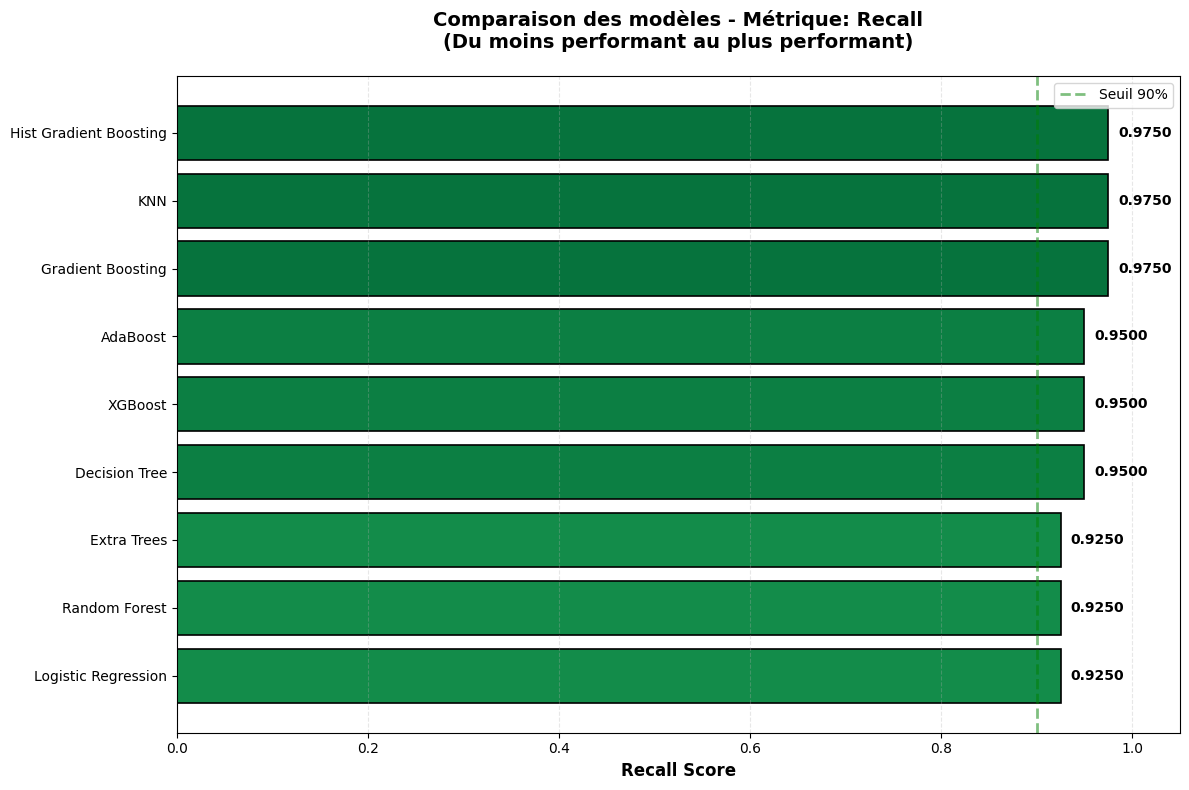

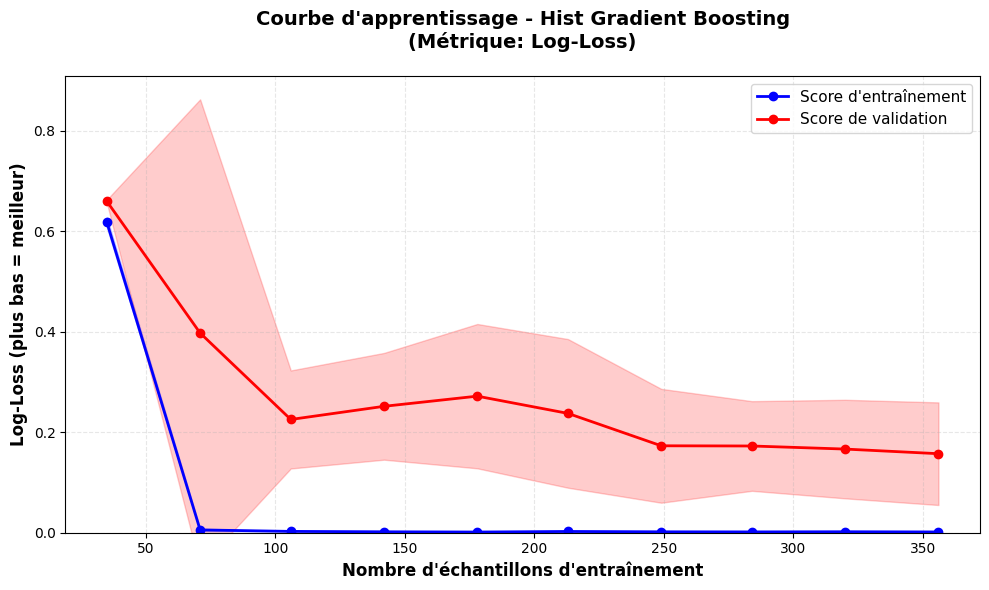

In [12]:
#  Lancer l'entrainement  
if __name__ == "__main__":
    # Charger vos données
    df = pd.read_csv('data/raw/cancer_clean.csv', sep=",")
    
    # Lancer la comparaison
    results, fig, rapport_meilleur_model, fig_learning, model_filename, scaler_filename  = compare_models(df)
    
    # Afficher le graphique
    plt.show()
        
    pass
    